### 1. 전처리 

In [1]:
# ======================================
# ✅ 1번 코드(수정): 전처리 + sat(연속)까지만 생성
# - sat_group(이진화)는 만들지 않음 (반드시 split 이후 train median으로 생성)
# ======================================

import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ============================================================
# 1. 데이터 로드
# ============================================================
df = pd.read_csv('univ355.csv')

# ============================================================
# 2. 대량 결측치 또는 의미 부족 변수 제거
# ============================================================
drop_missing_cols = [
    'why_not_rechoice', 'future_job_desc', 'income_class', 'income_contest',
    'income_perf', 'income_broadcast', 'income_studio', 'income_creator',
    'income_choreo', 'info_dept', 'info_career_center', 'info_online',
    'info_family', 'info_friends', 'info_academy', 'info_self',
    'help_financial', 'help_resume', 'help_career', 'help_social',
    'help_no', 'non_stay_reason', 'total_univ', 'id'
]
df = df.drop(columns=drop_missing_cols, errors='ignore')

# ============================================================
# 3. 지역 관련 중복 변수 제거
# ============================================================
current_area_cols = [col for col in df.columns if col.startswith('current_area')]
df = df.drop(columns=current_area_cols, errors='ignore')

# ============================================================
# 4. 오타 및 잘못된 범주값 정정
# ============================================================
if 'birth_area' in df.columns:
    df['birth_area'] = df['birth_area'].replace({'g': 'gangwon'})

# ============================================================
# 5. 범주형 변수 매핑 및 원-핫 인코딩
# ============================================================

# 5-1) 무용경력 구간 변환(ordinal coding)
midpoint_map = {'less2': 1, '2to4': 2, '4to7': 3, '7to10': 4, 'over10': 5}
if 'dance_years' in df.columns:
    df['dance_years'] = df['dance_years'].map(midpoint_map)

# 5-2) 범주형 변수 원-핫 인코딩 (drop_first=True)
columns_to_encode = [
    'univ_factor', 'major_factor', 'job_region', 'weight_control',
    'birth_area', 'housing_type', 'enter_type',
    'major_detail', 'univ_name', 'univ_area'
]
df = pd.get_dummies(
    df,
    columns=columns_to_encode,
    drop_first=True,
    dtype=float
)

# ============================================================
# 6. 사전 정의된 분석 제외 변수 제거
# ============================================================
remove_vars = ["prof_hi", "int_major", "enter_year"]
df = df.drop(columns=remove_vars, errors='ignore')

# ============================================================
# 7. 다중공선성 우려 변수 사전 제거
# ============================================================
high_corr_remove = ['lecture_qual', 'peer_personal', 'enjoy_major', 'prof_chat', 'peer_study']
df = df.drop(columns=high_corr_remove, errors='ignore')

# ============================================================
# 8. sat(연속) 지표 생성 (✅ 여기까지만!)
# ============================================================
sat_cols = ['univ_proud', 'univ_belong', 'major_proud', 'major_belong']
for c in sat_cols:
    if c not in df.columns:
        raise RuntimeError(f"sat 구성 문항 컬럼이 없습니다: {c}")

df['sat'] = df[sat_cols].mean(axis=1)

# ============================================================
# 9. 설명용 출력
# ============================================================
print("✅ 전처리 완료 (sat_group은 split 이후 train median으로 생성합니다)")
print("✅ 최종 데이터셋 컬럼 수:", df.shape[1])
print(df[['sat']].head())


✅ 전처리 완료 (sat_group은 split 이후 train median으로 생성합니다)
✅ 최종 데이터셋 컬럼 수: 166
    sat
0  4.00
1  4.50
2  3.00
3  3.00
4  4.75


### 2. 변수선택(K>24)

In [6]:
# ======================================
# ✅ 2번 코드(통합/재작성): 변수선택을 6:2:2 파이프라인 안으로 완전 통합
# - 목적: "변수선택 단계에서도 test를 절대 사용하지 않기"
#
# [반복(rep)마다]
# 1) split: (train_val/test)=80/20 → (train/val)=75/25  => 60/20/20
# 2) thr: median(sat_train) 로만 결정
# 3) y_train/y_val/y_test 생성(동일 thr 적용)
# 4) 변수선택은 오직 Train(60%)에서만 수행
# 5) 각 변수선택 결과로 LR(고정) 모델을 학습하여 Val(20%)에서만 성능 평가
# 6) rep마다 "Val 성능 기준"으로 1등 변수선택법을 기록
#
# 출력:
# - rep별 선택된 변수셋(각 방법별)
# - rep별 Val 성능(각 방법별)
# - rep별 Val 1등 선택 기록(best_pick_by_rep)
# - 방법별: (a) Val 평균±SD (b) rep 내 1등 빈도 (c) 선택 안정성(Jaccard/교집합/빈도)
# ======================================

import numpy as np
import pandas as pd
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV

from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) 필수 체크: df, sat
# -------------------------
if "df" not in globals():
    raise RuntimeError("df가 없습니다. 1번 코드(전처리)부터 실행하세요.")
if "sat" not in df.columns:
    raise RuntimeError("sat가 없습니다. 1번 코드에서 sat 생성 후 실행하세요.")

# -------------------------
# 1) X, sat 구성 (누수 방지: sat 및 sat 구성문항 제거)
# -------------------------
drop_target_related = ["sat", "univ_proud", "univ_belong", "major_proud", "major_belong"]
X_full = df.drop(columns=[c for c in drop_target_related if c in df.columns]).copy()
sat_full = df["sat"].copy()

# -------------------------
# 2) 유틸: 평균 pairwise Jaccard (선택 안정성)
# -------------------------
def mean_pairwise_jaccard(list_of_sets):
    if len(list_of_sets) < 2:
        return np.nan
    vals = []
    for i in range(len(list_of_sets)):
        for j in range(i + 1, len(list_of_sets)):
            a, b = list_of_sets[i], list_of_sets[j]
            inter = len(a & b)
            union = len(a | b)
            vals.append(inter / union if union > 0 else 0.0)
    return float(np.mean(vals)) if vals else np.nan

# -------------------------
# 3) 유틸: class=0 지표 (너의 정의 유지)
#   - recall_0 = TN/(TN+FP)  : specificity(저만족=0을 0으로 맞춘 비율)
#   - precision_0 = TN/(TN+FN)
#   - f1_0
# -------------------------
def class0_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    recall_0 = tn / (tn + fp) if (tn + fp) > 0 else np.nan
    precision_0 = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    f1_0 = (2 * precision_0 * recall_0 / (precision_0 + recall_0)) if (precision_0 + recall_0) > 0 else np.nan
    return recall_0, precision_0, f1_0

def get_score(fitted_model, X):
    # ROC-AUC용 score
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X)
    return None

# -------------------------
# 4) 변수선택 함수들 (Train에서만 사용)
# -------------------------
def enet_select(X_tr, y_tr, rs):
    """
    ElasticNet 임베디드 방식:
    - StandardScaler + LogisticRegressionCV(elasticnet)
    - coef != 0 인 변수 선택
    """
    selector = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegressionCV(
            Cs=20,
            cv=5,
            penalty="elasticnet",
            solver="saga",
            l1_ratios=[0.5],
            max_iter=10000,
            n_jobs=-1,
            random_state=rs
        ))
    ])
    selector.fit(X_tr, y_tr)
    coef = selector.named_steps["clf"].coef_.ravel()
    sel_cols = list(X_tr.columns[coef != 0])
    return sel_cols

def rfecv_select(method, X_tr, y_tr, rs):
    """
    RFECV 래퍼 방식:
    - method별 base estimator
    - scoring은 f1(기본). 필요하면 f1_macro 등으로 바꿀 수 있음.
    """
    if method == "LR":
        base = LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs)
        selector = Pipeline([
            ("scaler", StandardScaler()),
            ("rfecv", RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1))
        ])
        selector.fit(X_tr, y_tr)
        support = selector.named_steps["rfecv"].support_
        return list(X_tr.columns[support])

    if method == "DT":
        base = DecisionTreeClassifier(random_state=rs)
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        selector.fit(X_tr, y_tr)
        return list(X_tr.columns[selector.support_])

    if method == "RF":
        base = RandomForestClassifier(n_estimators=300, random_state=rs, n_jobs=-1)
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        selector.fit(X_tr, y_tr)
        return list(X_tr.columns[selector.support_])

    if method == "XGB":
        base = XGBClassifier(
            n_estimators=300,
            random_state=rs,
            eval_metric="logloss",
            n_jobs=-1
        )
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        selector.fit(X_tr, y_tr)
        return list(X_tr.columns[selector.support_])

    raise ValueError("method는 'LR','DT','RF','XGB' 중 하나여야 합니다.")

# -------------------------
# 5) "변수선택 결과"를 Val에서 평가하는 모델(고정)
#    - 변수선택 단계에서는 모델을 여러 개 비교하지 않고,
#      선택된 변수셋 품질을 보려는 목적이므로 LR로 고정(단순/일관)
#    - 이후 3번 코드에서 '모델까지 포함한 12조합'을 Val로 선택할 것임
# -------------------------
def fit_and_eval_on_val(X_tr, y_tr, X_va, y_va, rs):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
    ])
    fitted = model.fit(X_tr, y_tr)
    y_pred = fitted.predict(X_va)

    recall_0, precision_0, f1_0 = class0_metrics(y_va, y_pred)
    f1_macro = f1_score(y_va, y_pred, average="macro")
    bal_acc = balanced_accuracy_score(y_va, y_pred)
    acc = accuracy_score(y_va, y_pred)

    score = get_score(fitted, X_va)
    try:
        auc = roc_auc_score(y_va, score) if (score is not None and len(np.unique(y_va)) == 2) else np.nan
    except Exception:
        auc = np.nan

    return {
        "Val_recall_0": recall_0,
        "Val_precision_0": precision_0,
        "Val_f1_0": f1_0,
        "Val_f1_macro": f1_macro,
        "Val_balanced_acc": bal_acc,
        "Val_accuracy": acc,
        "Val_roc_auc": auc
    }

# -------------------------
# 6) ✅ Repeated Hold-out (6:2:2) 30회
#    - test는 이 코드에서 "절대 사용하지 않음"
# -------------------------
N_REP = 30
methods = ["ElasticNet", "RFECV(LR)", "RFECV(DT)", "RFECV(RF)", "RFECV(XGB)"]

# rep별 선택 변수셋 저장(안정성 분석용)
rep_selected_sets = {m: [] for m in methods}

# rep별 Val 성능 저장
rep_val_perf = {m: [] for m in methods}

# rep별 1등(Val 기준) 기록
best_pick_by_rep = []

for rep in range(N_REP):
    rs = RANDOM_STATE + rep

    # -------------------------
    # (1) 80/20 split: train_val / test  (✅ test 분리)
    # -------------------------
    X_train_val, X_test, sat_train_val, sat_test = train_test_split(
        X_full, sat_full,
        test_size=0.2,
        random_state=rs
    )

    # -------------------------
    # (2) 75/25 split: train / val  (✅ 0.8 안에서 0.25 => 최종 0.6/0.2)
    # -------------------------
    X_train, X_val, sat_train, sat_val = train_test_split(
        X_train_val, sat_train_val,
        test_size=0.25,
        random_state=rs
    )

    # -------------------------
    # (3) ✅ train median으로만 thr 결정 → y 생성
    # -------------------------
    thr = float(sat_train.median())
    y_train = (sat_train >= thr).astype(int)
    y_val   = (sat_val   >= thr).astype(int)

    # 주의: test는 여기서 y_test조차 만들지 않음(완전 봉인)
    # (원하면 만들어도 되지만, "변수선택 단계에서 test 미사용"을 더 명확히 하려고 생략)

    # -------------------------
    # (4) 변수선택: Train에서만
    # -------------------------
    # 4-1) ElasticNet
    cols_enet = enet_select(X_train, y_train, rs)
    rep_selected_sets["ElasticNet"].append(set(cols_enet))

    # 4-2) RFECV들
    cols_rlr  = rfecv_select("LR",  X_train, y_train, rs)
    cols_rdt  = rfecv_select("DT",  X_train, y_train, rs)
    cols_rrf  = rfecv_select("RF",  X_train, y_train, rs)
    cols_rxgb = rfecv_select("XGB", X_train, y_train, rs)

    rep_selected_sets["RFECV(LR)"].append(set(cols_rlr))
    rep_selected_sets["RFECV(DT)"].append(set(cols_rdt))
    rep_selected_sets["RFECV(RF)"].append(set(cols_rrf))
    rep_selected_sets["RFECV(XGB)"].append(set(cols_rxgb))

    # -------------------------
    # (5) Val 성능 평가: 선택된 변수셋 품질(모델은 LR로 고정)
    # -------------------------
    # 빈 변수셋 방어
    def safe_eval(cols, method_name):
        if cols is None or len(cols) == 0:
            out = {k: np.nan for k in ["Val_recall_0","Val_precision_0","Val_f1_0","Val_f1_macro","Val_balanced_acc","Val_accuracy","Val_roc_auc"]}
            out["n_features"] = 0
            return out
        metrics = fit_and_eval_on_val(
            X_train[cols], y_train,
            X_val[cols], y_val,
            rs
        )
        metrics["n_features"] = len(cols)
        return metrics

    perf_enet = safe_eval(cols_enet, "ElasticNet")
    perf_rlr  = safe_eval(cols_rlr,  "RFECV(LR)")
    perf_rdt  = safe_eval(cols_rdt,  "RFECV(DT)")
    perf_rrf  = safe_eval(cols_rrf,  "RFECV(RF)")
    perf_rxgb = safe_eval(cols_rxgb, "RFECV(XGB)")

    rep_val_perf["ElasticNet"].append({**perf_enet, "rep": rep, "random_state": rs})
    rep_val_perf["RFECV(LR)"].append({**perf_rlr,  "rep": rep, "random_state": rs})
    rep_val_perf["RFECV(DT)"].append({**perf_rdt,  "rep": rep, "random_state": rs})
    rep_val_perf["RFECV(RF)"].append({**perf_rrf,  "rep": rep, "random_state": rs})
    rep_val_perf["RFECV(XGB)"].append({**perf_rxgb, "rep": rep, "random_state": rs})
# -------------------------
# (6) rep 내 1등 변수선택법(Val 기준) 선정 (✅ Test 미사용)
#     ✅ 변경: Val_recall_0 -> Val_roc_auc -> Val_f1_macro 순으로 우선순위
# -------------------------
    rep_rows = []
    for m in methods:
        last = rep_val_perf[m][-1].copy()
        last["method"] = m
        rep_rows.append(last)

    rep_df = pd.DataFrame(rep_rows)

    # ✅ 우선순위 변경 (내림차순)
    rep_df = rep_df.sort_values(
        by=["Val_recall_0", "Val_roc_auc", "Val_f1_macro"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    best_pick_by_rep.append(rep_df.iloc[0].to_dict())

print(f"✅ 2번 코드 완료: 변수선택(Train) + Val 평가/선정 | {N_REP}회 반복(6:2:2) | test 미사용")

# -------------------------
# 7) 요약: 방법별 Val 평균±SD + 선택 빈도 + 안정성
# -------------------------
# 7-1) 방법별 Val 성능 요약(mean±SD)
CORE_VAL_METRICS = [
    "Val_recall_0", "Val_f1_0", "Val_f1_macro", "Val_balanced_acc", "Val_roc_auc", "n_features"
]

val_summary_rows = []
for m in methods:
    perf_df = pd.DataFrame(rep_val_perf[m])
    row = {"방법": m}
    for met in CORE_VAL_METRICS:
        row[f"{met}_mean"] = float(np.nanmean(perf_df[met]))
        row[f"{met}_std"]  = float(np.nanstd(perf_df[met], ddof=1))
    # 안정성 지표
    sets_ = rep_selected_sets[m]
    inter = set.intersection(*sets_) if len(sets_) > 0 else set()
    row["교집합_변수수"] = len(inter)
    row["Jaccard_mean"] = mean_pairwise_jaccard(sets_)
    val_summary_rows.append(row)

val_summary = pd.DataFrame(val_summary_rows).sort_values(
    by=["Val_recall_0_mean", "Val_f1_0_mean", "Val_balanced_acc_mean", "Val_roc_auc_mean"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

print("\n✅ [요약표] 변수선택 방법별 Val 성능(mean±SD) + 안정성")
display(val_summary)

# 7-2) rep별 1등 선택 빈도
best_picks_df = pd.DataFrame(best_pick_by_rep)
pick_count = (
    best_picks_df
    .groupby("method")
    .size()
    .reset_index(name="best_selected_count")
    .sort_values("best_selected_count", ascending=False)
    .reset_index(drop=True)
)
pick_count["best_selected_ratio"] = pick_count["best_selected_count"] / N_REP

print("\n✅ [빈도표] rep마다 Val 기준 1등으로 선택된 변수선택법 횟수")
display(pick_count)

# -------------------------
# 8) 교집합 변수/Top 빈도 변수(추가로 필요할 때)
# -------------------------
# (선택) 각 방법별 Top10 선택 빈도
for m in methods:
    freq = Counter()
    for s in rep_selected_sets[m]:
        freq.update(list(s))
    print(f"\n--- {m} | Top10 선택 빈도 ---")
    print(freq.most_common(10))

✅ 2번 코드 완료: 변수선택(Train) + Val 평가/선정 | 30회 반복(6:2:2) | test 미사용

✅ [요약표] 변수선택 방법별 Val 성능(mean±SD) + 안정성


,방법,Val_recall_0_mean,Val_recall_0_std,Val_f1_0_mean,Val_f1_0_std,Val_f1_macro_mean,Val_f1_macro_std,Val_balanced_acc_mean,Val_balanced_acc_std,Val_roc_auc_mean,Val_roc_auc_std,n_features_mean,n_features_std,교집합_변수수,Jaccard_mean
0,ElasticNet,0.755769,0.086145,0.745774,0.051828,0.786626,0.048703,0.790779,0.052570,0.864661,0.039417,42.033333,17.040486,3,0.342797
1,RFECV(RF),0.721735,0.092005,0.722351,0.060951,0.769518,0.055553,0.772833,0.057557,0.846990,0.050686,101.666667,41.371599,12,0.603755
2,RFECV(XGB),0.714642,0.109108,0.726212,0.082423,0.777149,0.062139,0.779172,0.062622,0.860241,0.054045,40.433333,21.343954,2,0.300300
3,RFECV(LR),0.705818,0.088928,0.709689,0.057207,0.761160,0.044466,0.763897,0.047200,0.833373,0.053976,26.166667,31.649027,0,0.162032
4,RFECV(DT),0.627045,0.136651,0.660240,0.081921,0.731015,0.056820,0.733279,0.055267,0.801006,0.059532,37.800000,58.326903,0,0.156391



✅ [빈도표] rep마다 Val 기준 1등으로 선택된 변수선택법 횟수


,method,best_selected_count,best_selected_ratio
0,ElasticNet,13,0.433333
1,RFECV(XGB),7,0.233333
2,RFECV(LR),4,0.133333
3,RFECV(DT),3,0.100000
4,RFECV(RF),3,0.100000



--- ElasticNet | Top10 선택 빈도 ---
[('students_diligent', 30), ('student_interact', 30), ('theory_cls', 30), ('prof_passion', 29), ('peer_external', 28), ('support_fac', 28), ('time_eff', 27), ('peer_event', 26), ('peer_advice', 26), ('prof_access', 24)]

--- RFECV(LR) | Top10 선택 빈도 ---
[('student_interact', 25), ('theory_cls', 23), ('support_fac', 23), ('students_diligent', 21), ('prof_passion', 17), ('job_region_yeongnam', 15), ('univ_name_swu', 14), ('univ_name_pku', 12), ('peer_event', 12), ('univ_factor_prefer_prof', 11)]

--- RFECV(DT) | Top10 선택 빈도 ---
[('student_interact', 22), ('prof_personal', 13), ('students_diligent', 12), ('theory_cls', 12), ('prof_passion', 10), ('univ_factor_prefer_prof', 10), ('housing_safety', 9), ('mental_health', 9), ('drop_out', 9), ('transport', 9)]

--- RFECV(RF) | Top10 선택 빈도 ---
[('prof_grade', 30), ('prof_access', 30), ('peer_external', 30), ('course_variety', 30), ('students_diligent', 30), ('support_fac', 30), ('peer_event', 30), ('student_int

### 2-1. 안정적변수 도출 

In [8]:
# ======================================
# ✅ 안정 변수셋(stable feature set) 생성: 선택빈도 기준
# - K=25 : 30회 중 25회 이상 선택된 변수
# - 방법별로 리스트 출력 + dict로 저장
# ======================================

from collections import Counter
import pandas as pd

# 안전 체크
if "rep_selected_sets" not in globals():
    raise RuntimeError("rep_selected_sets가 없습니다. 2번 코드(변수선택)를 먼저 실행하세요.")

N_REP = 30  # 현재 네 코드 기준
K_list = [25]

stable_sets = {}      # stable_sets[method][K] = [feature list]
stable_tables = {}    # stable_tables[method] = DataFrame(빈도표)

for method, set_list in rep_selected_sets.items():
    # set_list: 길이 30, 각 원소는 set(features)
    freq = Counter()
    for s in set_list:
        freq.update(list(s))
        
    # 빈도표 DataFrame (선택빈도 내림차순)
    freq_df = pd.DataFrame(freq.items(), columns=["feature", "count"]).sort_values(
        ["count", "feature"], ascending=[False, True]
    ).reset_index(drop=True)
    stable_tables[method] = freq_df
    
    stable_sets[method] = {}
    for K in K_list:
        feats = freq_df.loc[freq_df["count"] >= K, "feature"].tolist()
        stable_sets[method][K] = feats

# -------------------------
# ✅ 출력
# -------------------------
for method in rep_selected_sets.keys():
    print("\n" + "="*90)
    print(f"📌 {method} | 안정 변수셋(선택빈도 기준)")

    for K in K_list:
        feats = stable_sets[method][K]
        print(f"\n- K={K} (>= {K}/{N_REP}회 선택): {len(feats)}개")
        print(feats)

    

# -------------------------
# ✅ 바로 다음 코드(3번)에 쓰기 편하게:
# 예) ElasticNet의 K=25 변수셋
# -------------------------
vars_enet_k25 = stable_sets["ElasticNet"][25]
vars_rfecv_rf_k25 = stable_sets["RFECV(RF)"][25]
vars_rfecv_xgb_k25 = stable_sets["RFECV(XGB)"][25]
print("\n✅ (샘플) ElasticNet 변수셋 준비 완료")
print("\n✅ (샘플) RFECV(RF) 변수셋 준비 완료")
print("\n✅ (샘플) RFECV(XGB) 변수셋 준비 완료")
print("- vars_enet_k25:", len(vars_enet_k25))
print("- vars_rfecv_rf_k25:", len(vars_rfecv_rf_k25))
print("- vars_rfecv_xgb_k25:", len(vars_rfecv_xgb_k25))


📌 ElasticNet | 안정 변수셋(선택빈도 기준)

- K=25 (>= 25/30회 선택): 9개
['student_interact', 'students_diligent', 'theory_cls', 'prof_passion', 'peer_external', 'support_fac', 'time_eff', 'peer_advice', 'peer_event']

📌 RFECV(LR) | 안정 변수셋(선택빈도 기준)

- K=25 (>= 25/30회 선택): 1개
['student_interact']

📌 RFECV(DT) | 안정 변수셋(선택빈도 기준)

- K=25 (>= 25/30회 선택): 0개
[]

📌 RFECV(RF) | 안정 변수셋(선택빈도 기준)

- K=25 (>= 25/30회 선택): 68개
['course_variety', 'peer_advice', 'peer_event', 'peer_external', 'prof_access', 'prof_grade', 'prof_passion', 'prof_personal', 'student_interact', 'students_diligent', 'support_fac', 'theory_cls', 'admin_serv', 'ask_q', 'drink_freq', 'fit_major', 'know_reason', 'move_univ', 'peer_class', 'prac_cls', 'work_fee', 'car_spt', 'change_major', 'intern_abroad', 'lecture_fac', 'peer_career', 'physical_health', 'prof_career', 'prof_event', 'study_hard', 'time_eff', 'dance_years', 'exercise_reg', 'get_fdbk', 'housing_culture', 'housing_neighbor', 'mental_health', 'prof_effort', 'change_career', 'drop

### 3. 최적변수셋 모델학습 

In [13]:
# ======================================
# ✅ 3번 코드(깔끔버전): SD(std) 출력 제거 (mean만 출력)
# - K=25 안정 변수셋(2개) × 4개 모델 = 8조합
# - rep별 1등 기준: Val_recall_0(specificity) -> Val_roc_auc -> Val_f1_macro
# - 출력: mean만 / 소수점 3자리
# ======================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

# ✅ pandas 출력 옵션: 소수점 3자리
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) 필수 체크
# -------------------------
if "df" not in globals():
    raise RuntimeError("df가 없습니다. 1번 코드(전처리)부터 실행하세요.")
if "sat" not in df.columns:
    raise RuntimeError("sat가 없습니다. 1번 코드에서 sat 생성 후 실행하세요.")
if "vars_enet_k25" not in globals():
    raise RuntimeError("vars_enet_k25가 없습니다. K=25 안정 변수셋 생성 코드를 먼저 실행하세요.")
if "vars_rfecv_xgb_k25" not in globals():
    raise RuntimeError("vars_rfecv_xgb_k25가 없습니다. K=25 안정 변수셋 생성 코드를 먼저 실행하세요.")

# -------------------------
# 1) feature_sets 정의 (✅ 2개만)
# -------------------------
feature_sets = {
    "ElasticNet(K25)": vars_enet_k25,
    "RFECV(XGB)(K25)": vars_rfecv_xgb_k25,
}

# -------------------------
# 2) X 구성 (누수 방지: sat 및 sat 구성문항 제거)
# -------------------------
drop_target_related = ["sat", "univ_proud", "univ_belong", "major_proud", "major_belong"]
X_full = df.drop(columns=[c for c in drop_target_related if c in df.columns]).copy()
sat_full = df["sat"].copy()

# 변수셋 유효성 체크
for fs_name, cols in feature_sets.items():
    if cols is None or len(cols) == 0:
        raise RuntimeError(f"[{fs_name}] 변수셋이 비어 있습니다.")
    missing = [c for c in cols if c not in X_full.columns]
    if missing:
        raise RuntimeError(f"[{fs_name}] X_full에 없는 변수가 있습니다: {missing}")

# -------------------------
# 3) 모델 정의(4개)
# -------------------------
def get_models(rs):
    return {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
        ]),
        "DecisionTree": DecisionTreeClassifier(random_state=rs),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=rs, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            random_state=rs,
            eval_metric="logloss",
            n_jobs=-1
        )
    }

def get_score(fitted_model, X):
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X)
    return None

# -------------------------
# 4) class=0 지표 (specificity 포함)
# -------------------------
def class0_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan   # TN/(TN+FP)
    precision_0 = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    f1_0 = (2 * precision_0 * specificity / (precision_0 + specificity)) if (precision_0 + specificity) > 0 else np.nan
    return specificity, precision_0, f1_0

def safe_auc(y_true, score):
    try:
        if score is None or len(np.unique(y_true)) < 2:
            return np.nan
        return roc_auc_score(y_true, score)
    except Exception:
        return np.nan

# -------------------------
# 5) rep 1회에서 8조합 평가
# -------------------------
def evaluate_combos_one_rep(rep_id, X_train, sat_train, X_val, sat_val, X_test, sat_test, rs):
    thr = float(sat_train.median())

    y_train = (sat_train >= thr).astype(int)
    y_val   = (sat_val   >= thr).astype(int)
    y_test  = (sat_test  >= thr).astype(int)

    models = get_models(rs)
    rows = []

    for fs_name, cols in feature_sets.items():
        X_tr = X_train[cols].copy()
        X_va = X_val[cols].copy()
        X_te = X_test[cols].copy()

        for model_name, model in models.items():
            fitted = model.fit(X_tr, y_train)

            # --- Val ---
            val_pred  = fitted.predict(X_va)
            val_score = get_score(fitted, X_va)
            val_auc = safe_auc(y_val, val_score)

            val_spec, val_precision_0, val_f1_0 = class0_metrics(y_val, val_pred)
            val_bal_acc = balanced_accuracy_score(y_val, val_pred)
            val_acc = accuracy_score(y_val, val_pred)
            val_f1_macro = f1_score(y_val, val_pred, average="macro")

            # --- Test (보고용) ---
            test_pred  = fitted.predict(X_te)
            test_score = get_score(fitted, X_te)
            test_auc = safe_auc(y_test, test_score)

            test_spec, test_precision_0, test_f1_0 = class0_metrics(y_test, test_pred)
            test_bal_acc = balanced_accuracy_score(y_test, test_pred)
            test_acc = accuracy_score(y_test, test_pred)
            test_f1_macro = f1_score(y_test, test_pred, average="macro")

            rows.append({
                "rep": rep_id,
                "random_state": rs,
                "thr_train_median": thr,

                "변수셋": fs_name,
                "모델": model_name,
                "n_features": len(cols),

                # Val
                "Val_specificity": val_spec,
                "Val_f1_macro": val_f1_macro,
                "Val_roc_auc": val_auc,
                "Val_balanced_acc": val_bal_acc,
                "Val_accuracy": val_acc,

                # Test (보고용)
                "Test_specificity": test_spec,
                "Test_f1_macro": test_f1_macro,
                "Test_roc_auc": test_auc,
                "Test_balanced_acc": test_bal_acc,
                "Test_accuracy": test_acc,
            })

    return pd.DataFrame(rows)

# -------------------------
# 6) Repeated Hold-out (6:2:2) 30회
# -------------------------
N_REP = 30
all_rep_results = []
best_pick_rows = []

for rep in range(N_REP):
    rs = RANDOM_STATE + rep

    X_train_val, X_test, sat_train_val, sat_test = train_test_split(
        X_full, sat_full, test_size=0.2, random_state=rs
    )
    X_train, X_val, sat_train, sat_val = train_test_split(
        X_train_val, sat_train_val, test_size=0.25, random_state=rs
    )

    rep_df = evaluate_combos_one_rep(rep, X_train, sat_train, X_val, sat_val, X_test, sat_test, rs)
    all_rep_results.append(rep_df)

    # ✅ rep 내 1등 선정 기준: specificity -> AUC -> F1_macro
    rep_sorted = rep_df.sort_values(
        by=["Val_specificity", "Val_roc_auc", "Val_f1_macro"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    best_pick_rows.append(rep_sorted.iloc[0].to_dict())

res_rep_all = pd.concat(all_rep_results, ignore_index=True)
best_picks = pd.DataFrame(best_pick_rows)

print("✅ 3번 코드 완료: 8조합 × 30회 평가")
print("전체 기록 row 수:", res_rep_all.shape[0], "(예상:", N_REP * (len(feature_sets) * 4), ")")
print("best_picks row 수:", best_picks.shape[0], "(예상:", N_REP, ")")

# -------------------------
# 7) 조합별 평균(mean)만 요약 (✅ std 출력 제거)
# -------------------------
CORE_METRICS = [
    "Val_specificity", "Val_roc_auc", "Val_f1_macro", "Val_balanced_acc",
    "Test_specificity", "Test_roc_auc", "Test_f1_macro", "Test_balanced_acc",
]

summary_mean = (
    res_rep_all
    .groupby(["변수셋", "모델"])[CORE_METRICS]
    .mean()
    .reset_index()
)

# Val 기준 정렬(1등 기준과 동일)
summary_mean = summary_mean.sort_values(
    by=["Val_specificity", "Val_roc_auc", "Val_f1_macro"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n✅ [요약표] 8조합 평균 성능(Val 중심 + Test는 보고용) (mean만)")
display(summary_mean)

# -------------------------
# 8) rep마다 Val 1등으로 뽑힌 빈도표
# -------------------------
pick_count = (
    best_picks
    .groupby(["변수셋", "모델"])
    .size()
    .reset_index(name="best_selected_count")
    .sort_values("best_selected_count", ascending=False)
    .reset_index(drop=True)
)
pick_count["best_selected_ratio"] = pick_count["best_selected_count"] / N_REP

print("\n✅ [빈도표] rep마다 Val 기준 1등으로 선택된 횟수")
display(pick_count)

# -------------------------
# 9) 최종 랭킹(빈도 + 평균) (✅ std 없이)
# -------------------------
final_rank = summary_mean.merge(pick_count, on=["변수셋", "모델"], how="left")
final_rank["best_selected_count"] = final_rank["best_selected_count"].fillna(0).astype(int)
final_rank["best_selected_ratio"] = final_rank["best_selected_ratio"].fillna(0.0)

final_rank = final_rank.sort_values(
    by=["best_selected_count", "Val_specificity", "Val_roc_auc", "Val_f1_macro"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

TOP_N = 5
cols_to_show = [
    "변수셋", "모델", "best_selected_count", "best_selected_ratio",
    "Val_specificity", "Val_roc_auc", "Val_f1_macro", "Val_balanced_acc",
    "Test_specificity", "Test_roc_auc", "Test_f1_macro", "Test_balanced_acc",
]

print(f"\n✅ [최종 랭킹] Top {TOP_N} (빈도 + Val 평균 / Test는 보고용) (mean만)")
display(final_rank[cols_to_show].head(TOP_N))

top1 = final_rank.iloc[0]
print("\n🏁 최종 1순위 후보(Val 기준 선정 + 빈도 우선)")
print(f"- 변수셋: {top1['변수셋']} | 모델: {top1['모델']}")
print(f"- 선택 빈도: {top1['best_selected_count']}/{N_REP} ({top1['best_selected_ratio']:.1%})")
print(f"- Val_specificity(mean): {top1['Val_specificity']:.3f}")
print(f"- Val_roc_auc(mean): {top1['Val_roc_auc']:.3f}")
print(f"- Val_f1_macro(mean): {top1['Val_f1_macro']:.3f}")

print("\n📌 (보고용) 동일 조합의 Test 평균 성능")
print(f"- Test_specificity(mean): {top1['Test_specificity']:.3f}")
print(f"- Test_roc_auc(mean): {top1['Test_roc_auc']:.3f}")
print(f"- Test_f1_macro(mean): {top1['Test_f1_macro']:.3f}")

✅ 3번 코드 완료: 8조합 × 30회 평가
전체 기록 row 수: 240 (예상: 240 )
best_picks row 수: 30 (예상: 30 )

✅ [요약표] 8조합 평균 성능(Val 중심 + Test는 보고용) (mean만)


,변수셋,모델,Val_specificity,Val_roc_auc,Val_f1_macro,Val_balanced_acc,Test_specificity,Test_roc_auc,Test_f1_macro,Test_balanced_acc
0,ElasticNet(K25),LogisticRegression,0.763,0.907,0.829,0.828,0.771,0.910,0.833,0.831
1,RFECV(XGB)(K25),LogisticRegression,0.759,0.908,0.826,0.825,0.778,0.908,0.837,0.836
2,RFECV(XGB)(K25),RandomForest,0.718,0.877,0.783,0.783,0.747,0.870,0.790,0.791
3,ElasticNet(K25),RandomForest,0.718,0.882,0.786,0.787,0.713,0.880,0.782,0.783
4,ElasticNet(K25),XGBoost,0.718,0.865,0.775,0.777,0.696,0.853,0.763,0.764
5,RFECV(XGB)(K25),XGBoost,0.708,0.841,0.762,0.764,0.735,0.838,0.764,0.769
6,RFECV(XGB)(K25),DecisionTree,0.678,0.733,0.726,0.729,0.700,0.737,0.720,0.726
7,ElasticNet(K25),DecisionTree,0.677,0.731,0.720,0.724,0.696,0.740,0.727,0.732



✅ [빈도표] rep마다 Val 기준 1등으로 선택된 횟수


,변수셋,모델,best_selected_count,best_selected_ratio
0,ElasticNet(K25),LogisticRegression,8,0.267
1,RFECV(XGB)(K25),LogisticRegression,7,0.233
2,ElasticNet(K25),XGBoost,5,0.167
3,ElasticNet(K25),RandomForest,3,0.100
4,RFECV(XGB)(K25),DecisionTree,3,0.100
5,RFECV(XGB)(K25),RandomForest,2,0.067
6,RFECV(XGB)(K25),XGBoost,2,0.067



✅ [최종 랭킹] Top 5 (빈도 + Val 평균 / Test는 보고용) (mean만)


,변수셋,모델,best_selected_count,best_selected_ratio,Val_specificity,Val_roc_auc,Val_f1_macro,Val_balanced_acc,Test_specificity,Test_roc_auc,Test_f1_macro,Test_balanced_acc
0,ElasticNet(K25),LogisticRegression,8,0.267,0.763,0.907,0.829,0.828,0.771,0.910,0.833,0.831
1,RFECV(XGB)(K25),LogisticRegression,7,0.233,0.759,0.908,0.826,0.825,0.778,0.908,0.837,0.836
2,ElasticNet(K25),XGBoost,5,0.167,0.718,0.865,0.775,0.777,0.696,0.853,0.763,0.764
3,ElasticNet(K25),RandomForest,3,0.100,0.718,0.882,0.786,0.787,0.713,0.880,0.782,0.783
4,RFECV(XGB)(K25),DecisionTree,3,0.100,0.678,0.733,0.726,0.729,0.700,0.737,0.720,0.726



🏁 최종 1순위 후보(Val 기준 선정 + 빈도 우선)
- 변수셋: ElasticNet(K25) | 모델: LogisticRegression
- 선택 빈도: 8/30 (26.7%)
- Val_specificity(mean): 0.763
- Val_roc_auc(mean): 0.907
- Val_f1_macro(mean): 0.829

📌 (보고용) 동일 조합의 Test 평균 성능
- Test_specificity(mean): 0.771
- Test_roc_auc(mean): 0.910
- Test_f1_macro(mean): 0.833


✅ 반복홀드아웃 완료: 30회 | ROC 계산 가능 rep 수: 30

✅ [Test 성능 요약] 30회 반복(mean±SD, median[IQR])


,mean,std,median,q1,q3
Recall_0(specificity),0.771,0.076,0.768,0.731,0.811
F1(class0),0.795,0.056,0.797,0.762,0.819
Balanced_ACC,0.831,0.045,0.834,0.813,0.850
ROC_AUC,0.910,0.038,0.914,0.898,0.930



✅ [β 및 OR(0) 요약표] (저만족 관점 OR(0)=exp(-β))


,feature,beta_mean,beta_sd,pos_ratio(+),OR(0)_median,OR(0)_q2.5,OR(0)_q97.5
0,students_diligent,0.704,0.143,1.000,0.490,0.390,0.625
1,student_interact,0.696,0.181,1.000,0.504,0.319,0.685
2,support_fac,0.600,0.144,1.000,0.542,0.426,0.718
3,theory_cls,0.565,0.142,1.000,0.569,0.461,0.769
4,time_eff,0.518,0.171,1.000,0.611,0.394,0.764
5,prof_passion,0.454,0.158,1.000,0.631,0.495,0.860
6,peer_advice,0.331,0.225,0.967,0.738,0.432,1.045
7,peer_event,0.236,0.223,0.833,0.767,0.530,1.228
8,peer_external,0.299,0.166,0.967,0.771,0.525,0.984


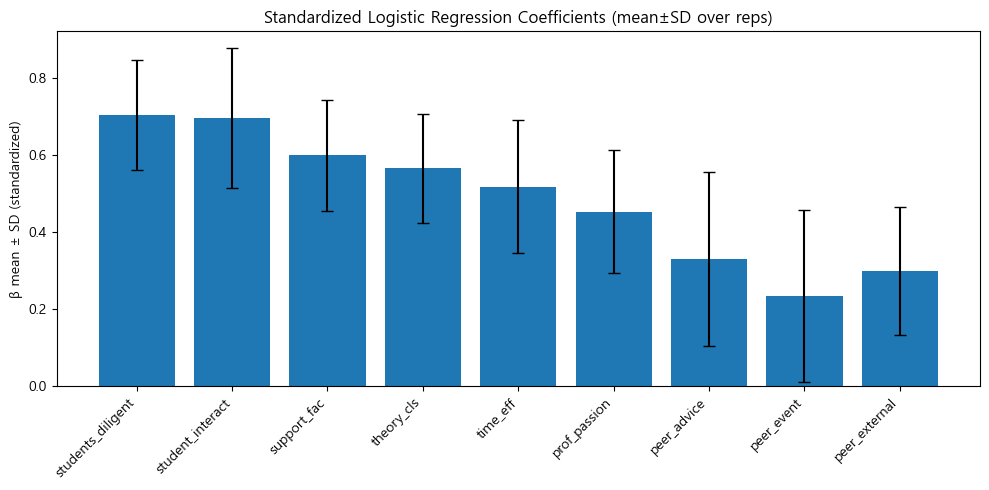

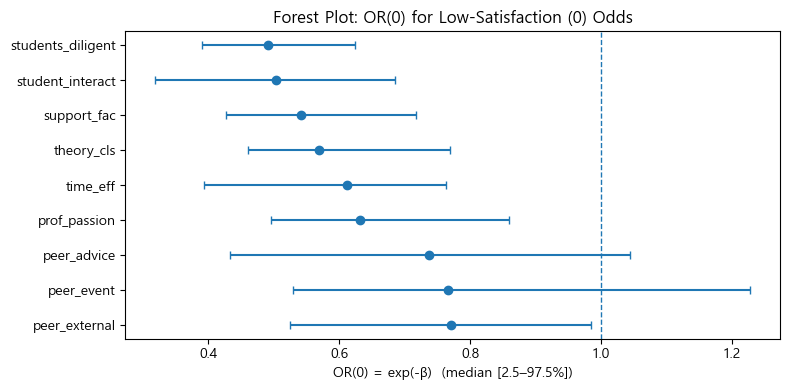

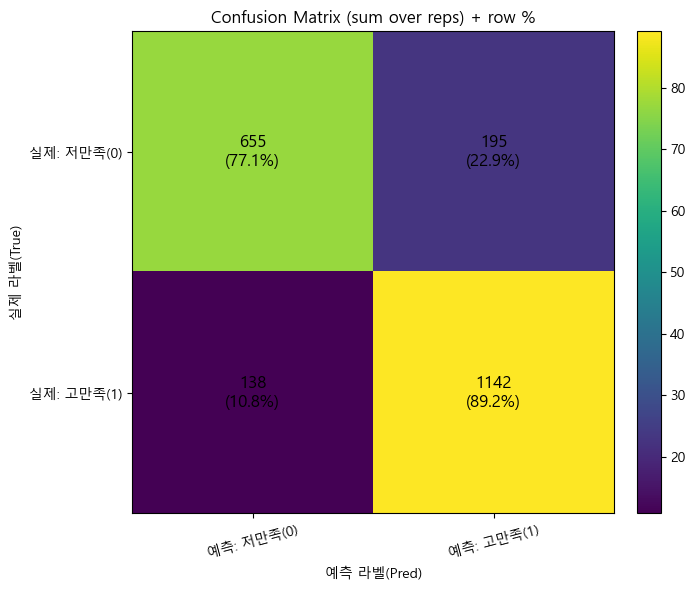


✅ [참고] 30회 합산 Confusion Matrix (raw count)
[[ 655  195]
 [ 138 1142]]


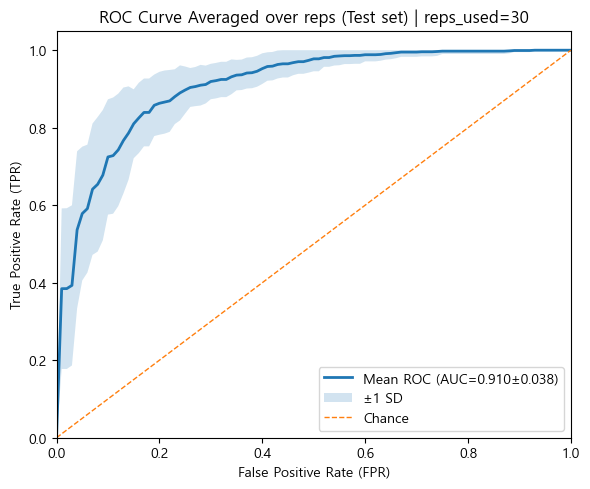

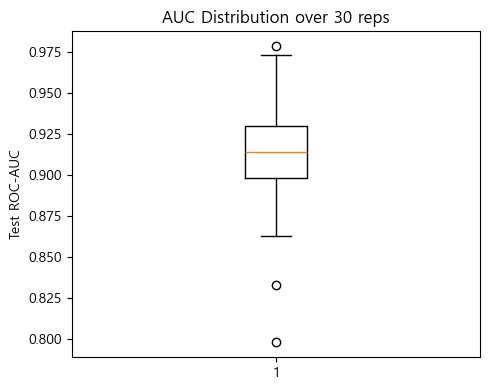

In [14]:
# ======================================
# ✅ 4번 코드(업그레이드): 최적모델(ElasticNet(K25)+LR)의
# (1) Test 성능 30회 요약(mean±SD, median[IQR])
# (2) β(표준화 계수) 안정성: mean±SD + 부호(+) 비율
# (3) OR(0)=exp(-β) 요약: median [2.5–97.5%] + Forest plot (저만족 관점)
# (4) 혼동행렬: 30회 합산 + 평균±SD
# (5) ROC curve: 평균 ROC + ±1SD band + AUC 분포
# --------------------------------------
# ⚠️ 누수 방지:
#   1) split 먼저 (X, sat 연속 기준)
#   2) thr = median(sat_train) (train에서만)
#   3) 동일 thr로 Train/Val/Test 라벨 생성
#   4) scaler는 Train에만 fit (Pipeline 내부)
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ✅ 한글 폰트 설정
import matplotlib.font_manager as fm
plt.rcParams["axes.unicode_minus"] = False
available_fonts = {f.name for f in fm.fontManager.ttflist}
for font_name in ["Malgun Gothic", "NanumGothic", "AppleGothic"]:
    if font_name in available_fonts:
        plt.rcParams["font.family"] = font_name
        break

# -------------------------
# 0) 필수 체크
# -------------------------
if "df" not in globals():
    raise RuntimeError("df가 없습니다. 1번 코드(전처리)부터 실행하세요.")
if "sat" not in df.columns:
    raise RuntimeError("sat가 없습니다. 1번 코드에서 sat 생성 후 실행하세요.")
if "vars_enet_k25" not in globals():
    raise RuntimeError("vars_enet_k25가 없습니다. K=25 안정 변수셋 생성 코드를 먼저 실행하세요.")

vars_final = vars_enet_k25  # ✅ 최종 변수셋(ElasticNet K25)

# -------------------------
# 1) X 구성 (누수 방지: sat 및 sat 구성문항 제거)
# -------------------------
drop_target_related = ["sat", "univ_proud", "univ_belong", "major_proud", "major_belong"]
X_full = df.drop(columns=[c for c in drop_target_related if c in df.columns]).copy()
sat_full = df["sat"].copy()

missing = [c for c in vars_final if c not in X_full.columns]
if missing:
    raise RuntimeError(f"vars_final 중 X_full에 없는 변수가 있습니다: {missing}")

# -------------------------
# 2) class=0 지표(혼동행렬 기반)
# -------------------------
def class0_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    recall_0 = tn / (tn + fp) if (tn + fp) > 0 else np.nan   # specificity
    precision_0 = tn / (tn + fn) if (tn + fn) > 0 else np.nan
    f1_0 = (2 * precision_0 * recall_0 / (precision_0 + recall_0)) if (precision_0 + recall_0) > 0 else np.nan
    return recall_0, precision_0, f1_0

# -------------------------
# 3) 최종 모델(고정): StandardScaler + LogisticRegression
# -------------------------
def build_final_model(rs):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
    ])

# -------------------------
# 4) Repeated Hold-out (6:2:2) 30회
# -------------------------
N_REP = 30

perf_rows = []
coef_mat = []         # (N_REP, n_features)
coef_sign_mat = []    # (N_REP, n_features)

cm_raw_list = []
cm_norm_list = []
roc_list = []

for rep in range(N_REP):
    rs = RANDOM_STATE + rep

    # (1) 80/20 split
    X_train_val, X_test, sat_train_val, sat_test = train_test_split(
        X_full, sat_full, test_size=0.2, random_state=rs
    )

    # (2) train/val (0.6/0.2)
    X_train, X_val, sat_train, sat_val = train_test_split(
        X_train_val, sat_train_val, test_size=0.25, random_state=rs
    )

    # (3) thr = train median
    thr = float(sat_train.median())

    # (4) 동일 thr로 라벨 생성
    y_train = (sat_train >= thr).astype(int)
    y_val   = (sat_val   >= thr).astype(int)   # 생성만(누수 방지 일관성)
    y_test  = (sat_test  >= thr).astype(int)

    # (5) 학습(train만)
    model = build_final_model(rs)
    fitted = model.fit(X_train[vars_final], y_train)

    # ---- Test 예측/점수 ----
    y_pred = fitted.predict(X_test[vars_final])
    y_score = fitted.predict_proba(X_test[vars_final])[:, 1]

    # ---- 성능 지표 ----
    recall_0, precision_0, f1_0 = class0_metrics(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    try:
        auc = roc_auc_score(y_test, y_score) if (len(np.unique(y_test)) == 2) else np.nan
    except Exception:
        auc = np.nan

    perf_rows.append({
        "rep": rep,
        "random_state": rs,
        "Test_Recall_0": recall_0,
        "Test_F1(class0)": f1_0,
        "Test_Balanced_ACC": bal_acc,
        "Test_ROC_AUC": auc,
        "thr_train_median": thr,
        "n_test": int(len(y_test)),
        "pos_rate_test": float(np.mean(y_test))
    })

    # ---- 계수 저장(표준화 계수) ----
    coefs = fitted.named_steps["clf"].coef_.ravel()  # (n_features,)
    coef_mat.append(coefs)
    coef_sign_mat.append((coefs > 0).astype(int))

    # ---- 혼동행렬 저장 ----
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    cm_raw_list.append(cm)

    with np.errstate(divide="ignore", invalid="ignore"):
        denom = cm.sum(axis=1, keepdims=True).astype(float)
        cm_norm = np.divide(cm.astype(float), denom, where=(denom != 0))
    cm_norm_list.append(cm_norm)

    # ---- ROC 저장 ----
    if len(np.unique(y_test)) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_score)
        roc_list.append({"fpr": fpr, "tpr": tpr})

print(f"✅ 반복홀드아웃 완료: {N_REP}회 | ROC 계산 가능 rep 수: {len(roc_list)}")

perf_df = pd.DataFrame(perf_rows)
coef_arr = np.vstack(coef_mat)          # (N_REP, n_features)
sign_arr = np.vstack(coef_sign_mat)     # (N_REP, n_features)

# -------------------------
# 5) 성능 요약(mean±SD + median[IQR])
# -------------------------
def summarize_series(s):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if len(s) == 0:
        return pd.Series({"mean": np.nan, "std": np.nan, "median": np.nan, "q1": np.nan, "q3": np.nan})
    return pd.Series({
        "mean": float(s.mean()),
        "std": float(s.std(ddof=1)),
        "median": float(s.median()),
        "q1": float(s.quantile(0.25)),
        "q3": float(s.quantile(0.75)),
    })

perf_summary = pd.concat([
    summarize_series(perf_df["Test_Recall_0"]).rename("Recall_0(specificity)"),
    summarize_series(perf_df["Test_F1(class0)"]).rename("F1(class0)"),
    summarize_series(perf_df["Test_Balanced_ACC"]).rename("Balanced_ACC"),
    summarize_series(perf_df["Test_ROC_AUC"]).rename("ROC_AUC"),
], axis=1).T

print("\n✅ [Test 성능 요약] 30회 반복(mean±SD, median[IQR])")
display(perf_summary)

# -------------------------
# 6) β 안정성 요약 + OR(0) 요약
# -------------------------
beta_mean = coef_arr.mean(axis=0)
beta_sd   = coef_arr.std(axis=0, ddof=1)
pos_ratio = sign_arr.mean(axis=0)

# OR(0) = exp(-beta) 를 반복별로 계산 → 분포요약
or0_arr = np.exp(-coef_arr)  # (N_REP, n_features)

or0_median = np.median(or0_arr, axis=0)
or0_q025   = np.quantile(or0_arr, 0.025, axis=0)
or0_q975   = np.quantile(or0_arr, 0.975, axis=0)

coef_table = pd.DataFrame({
    "feature": vars_final,
    "beta_mean": beta_mean,
    "beta_sd": beta_sd,
    "pos_ratio(+)": pos_ratio,
    "OR(0)_median": or0_median,
    "OR(0)_q2.5": or0_q025,
    "OR(0)_q97.5": or0_q975
}).sort_values("OR(0)_median", ascending=True).reset_index(drop=True)

print("\n✅ [β 및 OR(0) 요약표] (저만족 관점 OR(0)=exp(-β))")
display(coef_table)

# -------------------------
# 6-1) 시각화 A: β(mean±SD) 막대그래프 (표준화 계수)
# -------------------------
plt.figure(figsize=(10, 5))
x = np.arange(len(coef_table))
plt.bar(x, coef_table["beta_mean"].values, yerr=coef_table["beta_sd"].values, capsize=4)
plt.xticks(x, coef_table["feature"].values, rotation=45, ha="right")
plt.ylabel("β mean ± SD (standardized)")
plt.title("Standardized Logistic Regression Coefficients (mean±SD over reps)")
plt.tight_layout()
plt.show()

# -------------------------
# 6-2) 시각화 B: OR(0) Forest plot (median + 2.5–97.5%)
# -------------------------
plt.figure(figsize=(8, max(4, 0.35 * len(coef_table))))
ypos = np.arange(len(coef_table))

# 에러바: [median - q2.5, q97.5 - median]
xerr = np.vstack([
    coef_table["OR(0)_median"].values - coef_table["OR(0)_q2.5"].values,
    coef_table["OR(0)_q97.5"].values - coef_table["OR(0)_median"].values
])

plt.errorbar(
    coef_table["OR(0)_median"].values, ypos,
    xerr=xerr,
    fmt="o", capsize=3
)

plt.axvline(1.0, linestyle="--", linewidth=1)  # OR=1 기준선
plt.yticks(ypos, coef_table["feature"].values)
plt.xlabel("OR(0) = exp(-β)  (median [2.5–97.5%])")
plt.title("Forest Plot: OR(0) for Low-Satisfaction (0) Odds")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# -------------------------
# 7) 혼동행렬(합산 count + row%)
# -------------------------
cm_raw_arr = np.stack(cm_raw_list, axis=0)
cm_sum = cm_raw_arr.sum(axis=0).astype(int)

row_sums = cm_sum.sum(axis=1, keepdims=True)
cm_sum_rowpct = np.divide(cm_sum, row_sums, where=(row_sums != 0)) * 100

plt.figure(figsize=(7, 6))
plt.imshow(cm_sum_rowpct, interpolation="nearest")
plt.title("Confusion Matrix (sum over reps) + row %")
plt.colorbar(fraction=0.046, pad=0.04)

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["예측: 저만족(0)", "예측: 고만족(1)"], rotation=15)
plt.yticks(tick_marks, ["실제: 저만족(0)", "실제: 고만족(1)"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm_sum[i,j]}\n({cm_sum_rowpct[i,j]:.1f}%)", ha="center", va="center", fontsize=12)

plt.ylabel("실제 라벨(True)")
plt.xlabel("예측 라벨(Pred)")
plt.tight_layout()
plt.show()

print("\n✅ [참고] 30회 합산 Confusion Matrix (raw count)")
print(cm_sum)

# -------------------------
# 8) ROC 평균±SD band + AUC 분포
# -------------------------
if len(roc_list) >= 2:
    fpr_grid = np.linspace(0.0, 1.0, 101)
    tpr_interp_list = []

    for item in roc_list:
        fpr = item["fpr"]
        tpr = item["tpr"]
        tpr_interp = np.interp(fpr_grid, fpr, tpr)
        tpr_interp[0] = 0.0
        tpr_interp_list.append(tpr_interp)

    tpr_interp_arr = np.vstack(tpr_interp_list)
    mean_tpr = tpr_interp_arr.mean(axis=0)
    std_tpr  = tpr_interp_arr.std(axis=0, ddof=1)

    auc_series = perf_df["Test_ROC_AUC"].dropna()
    auc_mean = float(auc_series.mean()) if len(auc_series) > 0 else np.nan
    auc_std  = float(auc_series.std(ddof=1)) if len(auc_series) > 1 else np.nan

    plt.figure(figsize=(6, 5))
    plt.plot(fpr_grid, mean_tpr, linewidth=2,
             label=f"Mean ROC (AUC={auc_mean:.3f}±{auc_std:.3f})")

    tpr_upper = np.clip(mean_tpr + std_tpr, 0, 1)
    tpr_lower = np.clip(mean_tpr - std_tpr, 0, 1)
    plt.fill_between(fpr_grid, tpr_lower, tpr_upper, alpha=0.2, label="±1 SD")

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Chance")

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR)")
    plt.title(f"ROC Curve Averaged over reps (Test set) | reps_used={len(roc_list)}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5, 4))
    plt.boxplot(auc_series.values, vert=True)
    plt.ylabel("Test ROC-AUC")
    plt.title(f"AUC Distribution over {len(auc_series)} reps")
    plt.tight_layout()
    plt.show()
else:
    print("\n⚠️ ROC 평균화를 위한 유효 rep 수가 부족합니다(두 클래스가 모두 있는 test가 적음).")